In [1]:
#!pip install anaconda netcdf4 h5netcdf scipy pydap zarr fsspec cftime rasterio cfgrib pooch
#!pip install "xarray[netCDF4, h5netcdf, scipy, pydap, zarr, fsspec, cftime, rasterio, cfgrib, pooch]"
!pip install eccodes==1.2.0
!pip install cfgrib

import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime
from pathlib import Path

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Find nearest index
def find_index(array, x):
    if array.ndim == 1:
        idx = np.argmin(np.abs(array - x))
    elif array.ndim == 2:
        idx = np.unravel_index(np.argmin(np.abs(array - x)), array.shape)
    else:
        raise ValueError("Unsupported array dimensions for find_index function.")
    return idx

In [3]:
#Set working Directory for atm chem
result_dir = Path('/glade/campaign/acom/acom-climate/UTLS/shawnh/archive/FCnudged_f09.mam.mar27.2000_2021.001/atm/proc/tseries/month_1')

#Read in all files together and merge
bc_files_to_open = "FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.bc_*SFWET.200101-202212.nc"
pom_files_to_open = "FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.pom_*SFWET.200101-202212.nc"
soa_files_to_open = "FCnudged_f09.mam.mar27.2000_2021.001.cam.h0.soa*SFWET.200101-202212.nc"

nc_load_bc = xr.open_mfdataset(str(result_dir/bc_files_to_open),combine='nested')
nc_load_pom = xr.open_mfdataset(str(result_dir/pom_files_to_open),combine='nested')
nc_load_soa = xr.open_mfdataset(str(result_dir/soa_files_to_open),combine='nested')


/glade/u/home/demurray/.local/lib/python3.10/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfgrib' loading failed:
ecCodes library not found using ['eccodes', 'libeccodes.so', 'libeccodes']
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


In [8]:
#need to merge all the files but getting a ValueError on duplicate time stamp except for these files that I am merging.
bcpom_dataset = xr.merge([nc_load_bc, nc_load_pom])
#print(bcpom_dataset)

#Subset the a's and the c's from the bc and pom dataset
bcpom_a = bcpom_dataset[['pom_a1SFWET',  'pom_a4SFWET', 'bc_a1SFWET', 'bc_a4SFWET']]
bcpom_c = bcpom_dataset[['pom_c1SFWET',  'pom_c4SFWET', 'bc_c1SFWET', 'bc_c4SFWET']]

#subset the a's and c's from the soa dataset
soa_a = nc_load_soa[["soa1_a1SFWET", "soa1_a2SFWET", "soa2_a1SFWET", "soa2_a2SFWET", "soa3_a1SFWET", "soa3_a2SFWET",  
                     "soa4_a1SFWET", "soa4_a2SFWET", "soa5_a1SFWET", "soa5_a2SFWET"]]

soa_c = nc_load_soa[["soa1_c1SFWET", "soa1_c2SFWET", "soa2_c1SFWET", "soa2_c2SFWET","soa3_c1SFWET", "soa3_c2SFWET",   
                     "soa4_c1SFWET", "soa4_c2SFWET", "soa5_c1SFWET", "soa5_c2SFWET"]]

In [31]:
#From the a's BC and POM dataset: extract grid variables
lat = bcpom_a['lat']
lon = bcpom_a['lon']
var_sel_a = bcpom_a[['bc_a1SFWET','bc_a4SFWET', 'pom_a1SFWET', 'pom_a4SFWET']]

# CAM-chem writes the month average at midnight - i.e. the start of the next month.
# Reconfigure the time variable
time = bcpom_a['time']
time2 = pd.to_datetime(time.values,format='%Y-%m-%dT%H:%M:%S')+DateOffset(months=-1,days=+14)
print("file time: ", time[0].values, "---> converted time: ", time2[0])

#Select and extract the location
name_select = "Boulder"
lat_select = 40.0150
lon_select = 360-105.2705 # model longitude is from 0 to 360

lat_i = find_index(lat.values, lat_select)
lon_i = find_index(lon.values, lon_select)

print(name_select, " latitude: ", lat_select, "---> nearest: ", lat[lat_i].values)
print(name_select, " longitude: ", lon_select, "---> nearest: ", lon[lon_i].values)

conversions = 2.628e6*10000 #(seconds to months and m2 to hectare)
var_srf_a = var_sel_a.isel(lat=lat_i,lon=lon_i)*conversions*-1 #Convert to positive values, negative because its a flux TO surface

#From the SOA a dataset: extract grid variables
lat = soa_a['lat']
lon = soa_a['lon']
var_sel_soa_a = soa_a[["soa1_a1SFWET", "soa1_a2SFWET", "soa2_a1SFWET", "soa2_a2SFWET", "soa3_a1SFWET", "soa3_a2SFWET",  
                     "soa4_a1SFWET", "soa4_a2SFWET", "soa5_a1SFWET", "soa5_a2SFWET"]]

# CAM-chem writes the month average at midnight - i.e. the start of the next month.
# Reconfigure the time variable
time = nc_load_soa['time']
time2_soa_a = pd.to_datetime(time.values,format='%Y-%m-%dT%H:%M:%S')+DateOffset(months=-1,days=+14)
print("file time: ", time[0].values, "---> converted time: ", time2_soa_a[0])

#Select and extract the location
name_select = "Boulder"
lat_select = 40.0150
lon_select = 360-105.2705 # model longitude is from 0 to 360

lat_i = find_index(lat.values, lat_select)
lon_i = find_index(lon.values, lon_select)

print(name_select, " latitude: ", lat_select, "---> nearest: ", lat[lat_i].values)
print(name_select, " longitude: ", lon_select, "---> nearest: ", lon[lon_i].values)

var_srf_soa_a = var_sel_soa_a.isel(lat=lat_i,lon=lon_i)*conversions*-1 #Convert to positive values, negative because its a flux TO surface

file time:  2001-02-01T00:00:00.000000000 ---> converted time:  2001-01-15 00:00:00
Boulder  latitude:  40.015 ---> nearest:  40.0523560209424
Boulder  longitude:  254.7295 ---> nearest:  255.0


In [67]:
#From the c's BC and POM dataset: extract grid variables
lat = bcpom_c['lat']
lon = bcpom_c['lon']
var_sel_c = bcpom_c[['bc_c1SFWET','bc_c4SFWET', 'pom_c1SFWET', 'pom_c4SFWET']]

# CAM-chem writes the month average at midnight - i.e. the start of the next month.
# Reconfigure the time variable
time = bcpom_c['time']
time2c = pd.to_datetime(time.values,format='%Y-%m-%dT%H:%M:%S')+DateOffset(months=-1,days=+14)
print("file time: ", time[0].values, "---> converted time: ", time2c[0])

#Select and extract the location
name_select = "Boulder"
lat_select = 40.0150
lon_select = 360-105.2705 # model longitude is from 0 to 360

lat_i = find_index(lat.values, lat_select)
lon_i = find_index(lon.values, lon_select)

print(name_select, " latitude: ", lat_select, "---> nearest: ", lat[lat_i].values)
print(name_select, " longitude: ", lon_select, "---> nearest: ", lon[lon_i].values)

var_srf_c = var_sel_c.isel(lat=lat_i,lon=lon_i)*conversions*-1 #Convert to positive values, negative because its a flux TO surface

#From the SOA a dataset: extract grid variables
lat = soa_c['lat']
lon = soa_c['lon']
var_sel_soa_c = soa_c[["soa1_c1SFWET", "soa1_c2SFWET", "soa2_c1SFWET", "soa2_c2SFWET", "soa3_c1SFWET", "soa3_c2SFWET",  
                     "soa4_c1SFWET", "soa4_c2SFWET", "soa5_c1SFWET", "soa5_c2SFWET"]]

# CAM-chem writes the month average at midnight - i.e. the start of the next month.
# Reconfigure the time variable
time = nc_load_soa['time']
time2_soa_c = pd.to_datetime(time.values,format='%Y-%m-%dT%H:%M:%S')+DateOffset(months=-1,days=+14)
print("file time: ", time[0].values, "---> converted time: ", time2_soa_c[0])

#Select and extract the location
name_select = "Boulder"
lat_select = 40.0150
lon_select = 360-105.2705 # model longitude is from 0 to 360

lat_i = find_index(lat.values, lat_select)
lon_i = find_index(lon.values, lon_select)

print(name_select, " latitude: ", lat_select, "---> nearest: ", lat[lat_i].values)
print(name_select, " longitude: ", lon_select, "---> nearest: ", lon[lon_i].values)

var_srf_soa_c = var_sel_soa_c.isel(lat=lat_i,lon=lon_i)*conversions*-1 #Convert to positive values, negative because its a flux TO surface

file time:  2001-02-01T00:00:00.000000000 ---> converted time:  2001-01-15 00:00:00
Boulder  latitude:  40.015 ---> nearest:  40.0523560209424
Boulder  longitude:  254.7295 ---> nearest:  255.0
file time:  2001-02-01T00:00:00.000000000 ---> converted time:  2001-01-15 00:00:00
Boulder  latitude:  40.015 ---> nearest:  40.0523560209424
Boulder  longitude:  254.7295 ---> nearest:  255.0


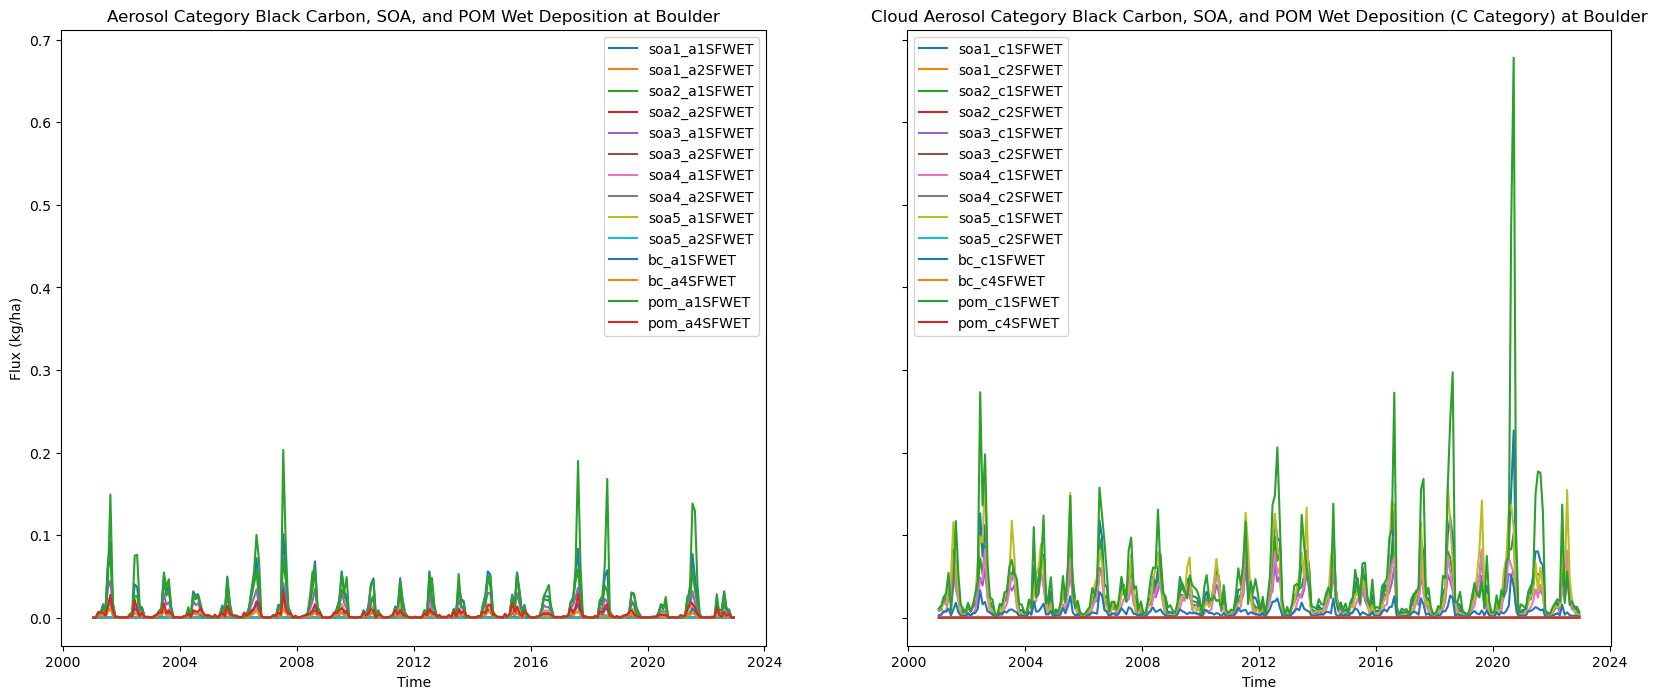

In [68]:
# Plot all 'a' category data variables as individual lines and in another panel plot all 'c' category lines
data_variables_soa_a = var_srf_soa_a.data_vars # Get all the SOA data variables in the dataset
data_variables_srf_a = var_srf_a.data_vars# Get all the data variables in the var_srf_a dataset (bc and pom)

data_variables_soa_c = var_srf_soa_c.data_vars # Get all the SOA data variables in the dataset
data_variables_srf_c = var_srf_c.data_vars# Get all the data variables in the var_srf_a dataset (bc and pom)

#plot it
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

#Aerosol category plot
for var_name, var_data in data_variables_soa_a.items():
    ax1.plot(time2_soa_a, var_data, label=var_name)
for var_name, var_data in data_variables_srf_a.items():
    ax1.plot(time2, var_data, label=var_name)
ax1.set_title('Aerosol Category Black Carbon, SOA, and POM Wet Deposition at ' + name_select)
ax1.set_xlabel('Time')
ax1.set_ylabel('Flux (kg/ha)')
ax1.legend()

# Plot all 'c' category data variables on the second panel
for var_name, var_data in data_variables_soa_c.items():
    ax2.plot(time2_soa_c, var_data, label=var_name)
for var_name, var_data in data_variables_srf_c.items():
    ax2.plot(time2c, var_data, label=var_name)
ax2.set_title('Cloud Aerosol Category Black Carbon, SOA, and POM Wet Deposition (C Category) at ' + name_select)
ax2.set_xlabel('Time')
ax2.legend()
plt.show()